<td width="45%" valign="middle">
  <div style="white-space: nowrap;">
    <img 
      src="https://www.upc.edu/comunicacio/ca/identitat/descarrega-arxius-grafics/fitxers-marca-principal/upc-positiu-p3005.png" 
      width="300"
      style="display:inline-block; vertical-align:middle;"
    >
    <img 
      src="https://www.hipotecalowcost.com/wp-content/uploads/2019/08/Logo-CaixaBank.png" 
      width="200"
      style="display:inline-block; vertical-align:middle;"
    >
  </div>
</td>

<td width="55%" align="right" valign="middle">
  <p style="margin: 0;"><b>Intelligence Data Science and Artificial Intelligence (IDEAI)</b></p>
  <p style="margin: 0;"><b>Grau en Estadística (UB - UPC)</b></p>
  <p style="margin: 0;">Anàlisis Multivariant de Dades (AMD)</p>
</td>


# **Modelos lineales generalizados (GLM): regresión logística**

Este notebook cubre el modelo logístico desde una perspectiva aplicada y comprensible:
- intuición,
- formulación,
- interpretación de coeficientes,
- odds y odds ratio,
- predicción,
- evaluación,
- regularización.

## Idea clave
La regresión logística modela la probabilidad de que ocurra un evento binario.

Ejemplos en auditoría:
- expediente irregular = 1 / no irregular = 0,
- mora = 1 / no mora = 0,
- alerta relevante = 1 / no relevante = 0.

In [87]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.datasets import load_breast_cancer, make_classification

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import log_loss, brier_score_loss
from sklearn.calibration import CalibrationDisplay
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

import statsmodels.api as sm

## 1. Recordatorio conceptual

La regresión lineal no sirve directamente para probabilidades porque puede dar valores menores que 0 o mayores que 1.

La regresión logística resuelve esto modelando:

$$
\text{logit}(p)=\log\left(\frac{p}{1-p}\right)=\beta_0+\beta_1x_1+\cdots+\beta_kx_k
$$

donde:
- $p = P(Y=1|X)$
- el logit transforma probabilidades en toda la recta real.

Luego recuperamos la probabilidad con:

$$
p = \frac{1}{1+e^{-z}}
$$

donde $z = \beta_0+\beta_1x_1+...+\beta_kx_k$

In [105]:
# Dataset base
data = pd.read_csv("dataset_bancario_clean.csv")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   cliente_id               5000 non-null   int64  
 1   edad                     5000 non-null   int64  
 2   antiguedad_cliente       5000 non-null   float64
 3   ingresos_mensuales       5000 non-null   float64
 4   situacion_laboral        5000 non-null   object 
 5   estado_civil             5000 non-null   object 
 6   nivel_estudios           5000 non-null   object 
 7   provincia_riesgo         5000 non-null   object 
 8   segmento_cliente         5000 non-null   object 
 9   num_productos            5000 non-null   int64  
 10  saldo_medio_3m           5000 non-null   float64
 11  limite_credito           5000 non-null   float64
 12  deuda_total              5000 non-null   float64
 13  cuota_mensual_prestamos  5000 non-null   float64
 14  utilizacion_credito     

In [ ]:
df = data.copy()
X = df.drop(columns="default")
y = df["default"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

In [89]:
# Detectar columnas numéricas y categóricas
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Numéricas:", num_cols)
print("Categóricas:", cat_cols)

Numéricas: ['cliente_id', 'edad', 'antiguedad_cliente', 'ingresos_mensuales', 'num_productos', 'saldo_medio_3m', 'limite_credito', 'deuda_total', 'cuota_mensual_prestamos', 'utilizacion_credito', 'porcentaje_ahorro', 'ratio_endeudamiento', 'retrasos_30d_12m', 'retrasos_60d_12m', 'retrasos_90d_12m', 'impagos_previos', 'consultas_credito_6m', 'nuevas_cuentas_12m', 'uso_banca_digital', 'alertas_fraude_12m', 'reclamaciones_12m', 'tiene_hipoteca', 'tiene_prestamo_personal', 'tiene_tarjeta_credito', 'tiene_seguro', 'score_interno']
Categóricas: ['situacion_laboral', 'estado_civil', 'nivel_estudios', 'provincia_riesgo', 'segmento_cliente']


## 2. Entrenamiento de un primer modelo logístico

In [90]:
# Transformación para numéricas
num_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Transformación para categóricas
cat_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

# Preprocesador conjunto
preprocessor = ColumnTransformer([
    ("num", num_transformer, num_cols),
    ("cat", cat_transformer, cat_cols)
])

In [91]:
logit = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=5000, random_state=0))
])

logit.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['cliente_id', 'edad',
                                                   'antiguedad_cliente',
                                                   'ingresos_mensuales',
                                                   'num_productos',
                                                   'saldo_medio_3m',
                                                   'limite_credito',
                                                   'deuda_total',
                                                   'cuota_mensual_prestamos',
                                                   'utilizacion_credito',
                                                   'porcentaje_a...
                                                   'tiene_tarjeta_credito',
                                                   'tiene_seguro',
                                                   'score_interno']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['situacion_laboral',
                                                   'estado_civil',
                                                   'nivel_estudios',
                                                   'provincia_riesgo',
                                                   'segmento_cliente'])])),
                ('model', LogisticRegression(max_iter=5000, random_state=0))])

In [92]:
# Convertir categóricas a variables dummy
X = pd.get_dummies(X, drop_first=True)
X = X.astype(float)

X_train_sm, X_test_sm, y_train_sm, y_test_sm = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

X_train_sm = sm.add_constant(X_train_sm)
X_test_sm = sm.add_constant(X_test_sm, has_constant="add")

model = sm.Logit(y_train_sm, X_train_sm)
result = model.fit()

print(result.summary())


Optimization terminated successfully.
         Current function value: 0.045479
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:                default   No. Observations:                 3750
Model:                          Logit   Df Residuals:                     3709
Method:                           MLE   Df Model:                           40
Date:               mi., 08 abr. 2026   Pseudo R-squ.:                  0.3247
Time:                        12:17:46   Log-Likelihood:                -170.54
converged:                       True   LL-Null:                       -252.53
Covariance Type:            nonrobust   LLR p-value:                 6.042e-17
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const                             4.9994      5.310      0.942      0

In [93]:
pred = logit.predict(X_test)
proba = logit.predict_proba(X_test)[:, 1]

[[1233    2]
 [  13    2]]


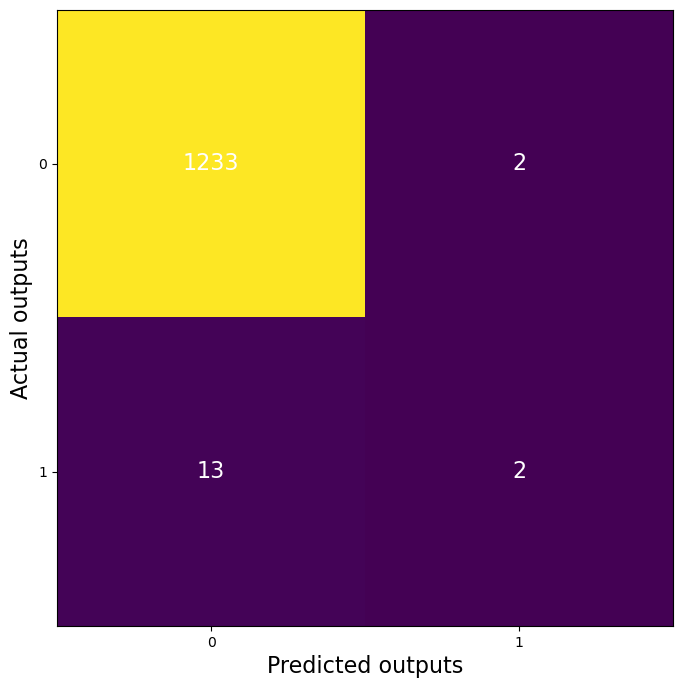

In [103]:
print(confusion_matrix(y_test, pred))

cm = confusion_matrix(y_test, pred)

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(cm)
ax.grid(False)
ax.set_xlabel('Predicted outputs', fontsize=16, color='black')
ax.set_ylabel('Actual outputs', fontsize=16, color='black')
ax.xaxis.set(ticks=range(2))
ax.yaxis.set(ticks=range(2))
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center', color='white', fontsize=16)
plt.show()


In [ ]:
print("Accuracy :", round(accuracy_score(y_test, pred), 4))
print("Precision:", round(precision_score(y_test, pred), 4))
print("Recall   :", round(recall_score(y_test, pred), 4))
print("F1       :", round(f1_score(y_test, pred), 4))
print("ROC AUC  :", round(roc_auc_score(y_test, proba), 4))
print("LogLoss  :", round(log_loss(y_test, proba), 4))
print("Brier    :", round(brier_score_loss(y_test, proba), 4))

[[1233    2]
 [  13    2]]


Accuracy : 0.988
Precision: 0.5
Recall   : 0.1333
F1       : 0.2105
ROC AUC  : 0.7263
LogLoss  : 0.0606
Brier    : 0.0111


In [ ]:
print(classification_report(y_test, logit.predict(X_test)))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1235
           1       0.50      0.13      0.21        15

    accuracy                           0.99      1250
   macro avg       0.74      0.57      0.60      1250
weighted avg       0.98      0.99      0.98      1250



## 3. Interpretación de probabilidades

`predict_proba` devuelve probabilidades estimadas.  
Por ejemplo, si una observación tiene 0.92, el modelo estima un 92% de probabilidad de clase 1.

In [ ]:
logit.predict_proba(X_test)

array([[9.99175364e-01, 8.24636147e-04],
       [9.77212727e-01, 2.27872727e-02],
       [9.82689724e-01, 1.73102755e-02],
       ...,
       [9.98422339e-01, 1.57766112e-03],
       [9.86401696e-01, 1.35983042e-02],
       [9.98876737e-01, 1.12326299e-03]])

In [ ]:
logit.predict(X_test)

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [ ]:
pd.DataFrame({
    "real": y_test[:10].reset_index(drop=True),
    "prob_1": proba[:10],
    "pred_clase": pred[:10]
})

,real,prob_1,pred_clase
0,0,0.000825,0
1,0,0.022787,0
2,0,0.017310,0
3,0,0.005463,0
4,0,0.004522,0
5,0,0.009994,0
6,0,0.004198,0
7,0,0.003180,0
8,0,0.077607,0
9,0,0.001565,0


## 4. Interpretación de coeficientes

Los coeficientes están en escala de **log-odds**.  
Si exponenciamos un coeficiente, obtenemos un **odds ratio**.

- Si OR > 1: al aumentar la variable, aumentan las odds de clase 1.
- Si OR < 1: al aumentar la variable, disminuyen las odds de clase 1.

In [ ]:
model = logit.named_steps["model"]
model

LogisticRegression(max_iter=5000)

In [ ]:
model.coef_[0]

array([-0.28377775, -0.06198678, -0.07003916, -0.61418494,  0.16135439,
       -0.11669339, -0.08635763, -0.08434512,  0.10533553,  0.00081006,
       -0.02328402,  0.05571756,  0.19052166,  0.27372303,  0.33477025,
        0.37332382,  0.28450853,  0.2052633 ,  0.1301806 , -0.10112133,
        0.07218965,  0.03928066, -0.0990318 ,  0.0363852 ,  0.09281247,
       -0.5318026 , -0.2512685 ,  0.60517147, -0.16966615,  0.21374654,
       -0.37368435,  0.06411849, -0.44120486,  0.57254143,  0.28075893,
        0.11297042, -0.5326545 , -0.06272662, -0.50460125, -0.54699878])

In [ ]:
feature_names = logit.named_steps["preprocessor"].get_feature_names_out()
coef_values = logit.named_steps["model"].coef_[0]

coefs = pd.DataFrame({
    "variable": feature_names,
    "coef_logit": coef_values
}).sort_values("coef_logit", ascending=False)

coefs.head(20)

,variable,coef_logit
27,cat__situacion_laboral_desempleado,0.605171
33,cat__nivel_estudios_medios,0.572541
15,num__impagos_previos,0.373324
14,num__retrasos_90d_12m,0.334770
16,num__consultas_credito_6m,0.284509
34,cat__nivel_estudios_postgrado,0.280759
13,num__retrasos_60d_12m,0.273723
29,cat__situacion_laboral_temporal,0.213747
17,num__nuevas_cuentas_12m,0.205263
12,num__retrasos_30d_12m,0.190522


In [ ]:
coefs["odds_ratio"] = np.exp(coefs["coef_logit"])
coefs["abs_coef"] = coefs["coef_logit"].abs()
coefs.sort_values("abs_coef", ascending=False).head(15)

,variable,coef_logit,odds_ratio,abs_coef
3,num__ingresos_mensuales,-0.614185,0.541082,0.614185
27,cat__situacion_laboral_desempleado,0.605171,1.831566,0.605171
33,cat__nivel_estudios_medios,0.572541,1.772767,0.572541
39,cat__segmento_cliente_medio,-0.546999,0.578684,0.546999
36,cat__provincia_riesgo_bajo,-0.532654,0.587045,0.532654
25,num__score_interno,-0.531803,0.587545,0.531803
38,cat__segmento_cliente_bajo,-0.504601,0.603746,0.504601
32,cat__estado_civil_viudo,-0.441205,0.643261,0.441205
30,cat__estado_civil_divorciado,-0.373684,0.688194,0.373684
15,num__impagos_previos,0.373324,1.452555,0.373324


## 5. Umbral de clasificación

Por defecto, muchas veces se usa 0.5:
- si p >= 0.5, predecimos clase 1,
- si p < 0.5, predecimos clase 0.

Pero ese umbral puede cambiar según negocio.

In [ ]:
for thr in [0.3, 0.5, 0.7]:
    pred_thr = (proba >= thr).astype(int)
    print(f"Umbral = {thr}")
    print("  Accuracy:", round(accuracy_score(y_test, pred_thr), 4))
    print("  Precision:", round(precision_score(y_test, pred_thr), 4))
    print("  Recall   :", round(recall_score(y_test, pred_thr), 4))
    print("  F1       :", round(f1_score(y_test, pred_thr), 4))

Umbral = 0.3
  Accuracy: 0.9872
  Precision: 0.4286
  Recall   : 0.2
  F1       : 0.2727
Umbral = 0.5
  Accuracy: 0.988
  Precision: 0.5
  Recall   : 0.1333
  F1       : 0.2105
Umbral = 0.7
  Accuracy: 0.9872
  Precision: 0.0
  Recall   : 0.0
  F1       : 0.0


## 6. Curvas ROC y Precision-Recall

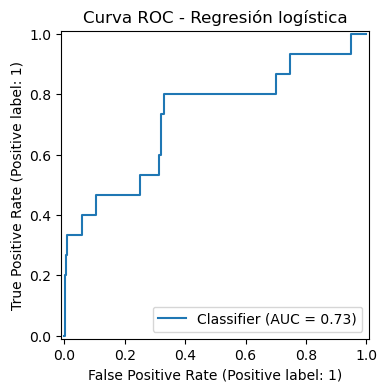

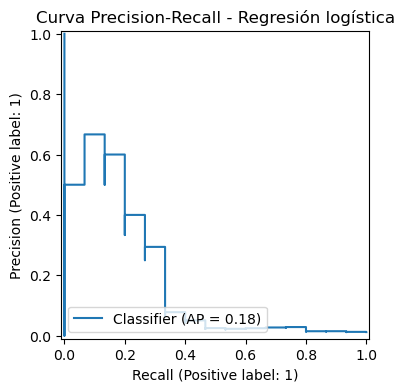

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
RocCurveDisplay.from_predictions(y_test, proba, ax=ax)
plt.title("Curva ROC - Regresión logística")
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
PrecisionRecallDisplay.from_predictions(y_test, proba, ax=ax)
plt.title("Curva Precision-Recall - Regresión logística")
plt.show()

## 7. Calibración

Un modelo puede clasificar bien pero estar mal calibrado.  
Calibración significa que las probabilidades emitidas tengan sentido probabilístico.

Si el modelo asigna 0.8 a 100 casos, esperaríamos que aproximadamente 80 fueran realmente positivos.

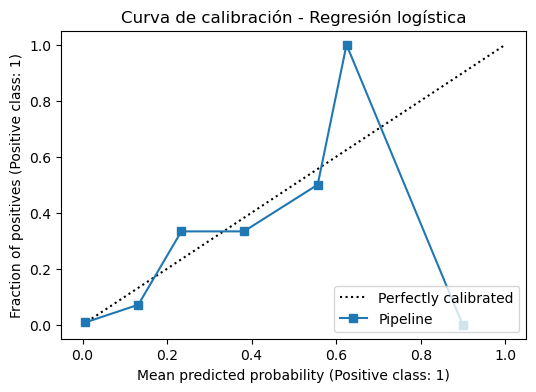

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
CalibrationDisplay.from_estimator(logit, X_test, y_test, n_bins=10, ax=ax)
plt.title("Curva de calibración - Regresión logística")
plt.show()

## 8. Regularización

En `sklearn`, la regresión logística incorpora regularización por defecto.

- **L2**: penaliza coeficientes grandes de manera suave.
- **L1**: puede forzar algunos coeficientes a 0 y ayuda en selección de variables.

El parámetro `C` controla la fuerza inversa de la regularización:
- C pequeño = más regularización,
- C grande = menos regularización.

In [ ]:
for C in [0.01, 0.1, 1, 10]:
    model = Pipeline([
        ("preprocessor", preprocessor),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=5000, C=C))
    ])
    model.fit(X_train, y_train)
    proba_c = model.predict_proba(X_test)[:, 1]
    print(f"C={C:>4} | ROC AUC={roc_auc_score(y_test, proba_c):.4f}")

C=0.01 | ROC AUC=0.7786
C= 0.1 | ROC AUC=0.7406
C=   1 | ROC AUC=0.7142
C=  10 | ROC AUC=0.7052


## 9. Dataset sintético para visualizar la frontera de decisión

A veces es útil ver la frontera de decisión en 2 dimensiones.

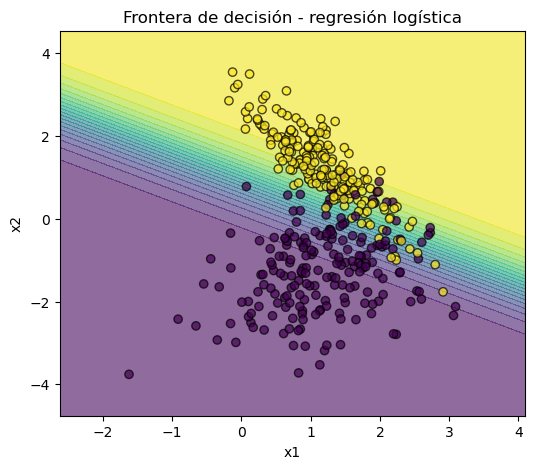

In [ ]:
X_syn, y_syn = make_classification(
    n_samples=400, n_features=2, n_redundant=0, n_informative=2,
    n_clusters_per_class=1, class_sep=1.2, random_state=42
)

X_syn = pd.DataFrame(X_syn, columns=["x1", "x2"])

Xtr, Xte, ytr, yte = train_test_split(X_syn, y_syn, test_size=0.25, random_state=42)

viz_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression())
])
viz_model.fit(Xtr, ytr)

# Malla para representar probabilidades
xx, yy = np.meshgrid(
    np.linspace(X_syn["x1"].min()-1, X_syn["x1"].max()+1, 200),
    np.linspace(X_syn["x2"].min()-1, X_syn["x2"].max()+1, 200)
)
grid = pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=["x1", "x2"])
zz = viz_model.predict_proba(grid)[:, 1].reshape(xx.shape)

plt.figure(figsize=(6, 5))
plt.contourf(xx, yy, zz, levels=20, alpha=0.6)
plt.scatter(X_syn["x1"], X_syn["x2"], c=y_syn, edgecolor="k", alpha=0.7)
plt.title("Frontera de decisión - regresión logística")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

## 10. Ventajas y limitaciones

### Ventajas
- Simple de explicar.
- Muy útil como baseline.
- Probabilidades interpretables.
- Buen comportamiento en muchos problemas tabulares.

### Limitaciones
- Supone relación lineal en el logit.
- Puede quedarse corta ante relaciones muy no lineales.
- Sensible a colinealidad y outliers en ciertos contextos.

## 11. Ejercicios propuestos

### Ejercicio 1
Entrena una regresión logística sobre el dataset y calcula la matriz de confusión.

In [ ]:
# Escribe aquí tu solución

### Ejercicio 2
Obtén las probabilidades de las primeras 15 observaciones de test.

In [ ]:
# Escribe aquí tu solución

### Ejercicio 3
Calcula accuracy, precision, recall, F1 y ROC AUC.

In [ ]:
# Escribe aquí tu solución

### Ejercicio 4
Extrae los coeficientes y ordénalos por valor absoluto.

In [ ]:
# Escribe aquí tu solución

### Ejercicio 5
Calcula los odds ratio y comenta qué significa uno mayor que 1.

In [ ]:
# Escribe aquí tu solución

### Ejercicio 6
Prueba umbrales 0.2, 0.5 y 0.8 y compara precision y recall.

In [ ]:
# Escribe aquí tu solución

### Ejercicio 7
Entrena modelos con C=0.01, 0.1, 1 y 10 y compara ROC AUC.

In [ ]:
# Escribe aquí tu solución

### Ejercicio 8
Calcula log loss y Brier score.

In [ ]:
# Escribe aquí tu solución

### Ejercicio 9
Representa la curva de calibración del modelo.

In [ ]:
# Escribe aquí tu solución

### Ejercicio 10
Usa validación cruzada de 5 folds para estimar el ROC AUC medio.

In [ ]:
# Escribe aquí tu solución

# Solucionario

In [ ]:
# Solución 1
from sklearn.metrics import confusion_matrix
logit = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=5000))
])
logit.fit(X_train, y_train)
pred = logit.predict(X_test)
confusion_matrix(y_test, pred)

In [ ]:
# Solución 2
proba = logit.predict_proba(X_test)[:, 1]
proba[:15]

In [ ]:
# Solución 3
print("Accuracy :", accuracy_score(y_test, pred))
print("Precision:", precision_score(y_test, pred))
print("Recall   :", recall_score(y_test, pred))
print("F1       :", f1_score(y_test, pred))
print("ROC AUC  :", roc_auc_score(y_test, proba))

In [ ]:
# Solución 4
coefs = pd.DataFrame({
    "variable": X.columns,
    "coef": logit.named_steps["model"].coef_[0]
})
coefs["abs_coef"] = coefs["coef"].abs()
coefs.sort_values("abs_coef", ascending=False).head(10)

In [ ]:
# Solución 5
coefs["odds_ratio"] = np.exp(coefs["coef"])
coefs.sort_values("odds_ratio", ascending=False).head()

In [ ]:
# Solución 6
for thr in [0.2, 0.5, 0.8]:
    pred_thr = (proba >= thr).astype(int)
    print(thr, precision_score(y_test, pred_thr), recall_score(y_test, pred_thr))

In [ ]:
# Solución 7
for C in [0.01, 0.1, 1, 10]:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=5000, C=C))
    ])
    model.fit(X_train, y_train)
    proba_c = model.predict_proba(X_test)[:, 1]
    print(C, roc_auc_score(y_test, proba_c))

In [ ]:
# Solución 8
print("Log loss :", log_loss(y_test, proba))
print("Brier    :", brier_score_loss(y_test, proba))

In [ ]:
# Solución 9
fig, ax = plt.subplots(figsize=(6, 4))
CalibrationDisplay.from_estimator(logit, X_test, y_test, n_bins=10, ax=ax)
plt.show()

In [ ]:
# Solución 10
scores = cross_val_score(logit, X, y, cv=5, scoring="roc_auc")
print(scores)
print(scores.mean())